In [1]:
import numpy as np 
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt

In [2]:
url = "http://www.stat.cmu.edu/~larry/=stat401/auto-mpg.csv"

resp = requests.get(url, verify=False)
resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text))
df.to_csv("auto-mpg.csv", index=False)

print(df.head())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.stat.cmu.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


                    car.name   mpg  weight
0  chevrolet chevelle malibu  18.0    3504
1          buick skylark 320  15.0    3693
2         plymouth satellite  18.0    3436
3              amc rebel sst  16.0    3433
4                ford torino  17.0    3449


In [3]:
desc = df.describe()
desc.loc["num_NaNs"] = df.isna().sum()
desc

,mpg,weight
count,398.000000,398.000000
mean,23.514573,2970.424623
std,7.815984,846.841774
min,9.000000,1613.000000
25%,17.500000,2223.750000
50%,23.000000,2803.500000
75%,29.000000,3608.000000
max,46.600000,5140.000000
num_NaNs,0.000000,0.000000


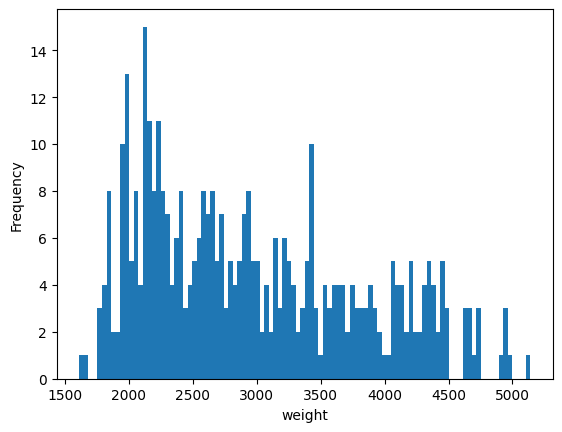

In [4]:
plt.hist(df["weight"].dropna(), bins=100) 
# plt.xscale("log")
plt.xlabel("weight")
plt.ylabel("Frequency")
plt.show()

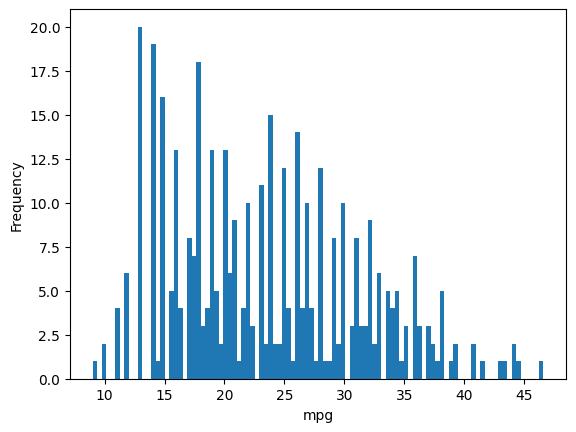

In [5]:
plt.hist(df["mpg"].dropna(), bins=100) 
# plt.xscale("log")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

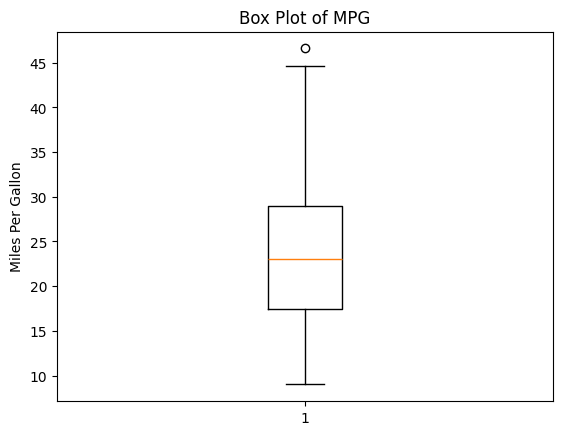

In [6]:
plt.boxplot(df["mpg"].dropna(), vert=True)
plt.ylabel("Miles Per Gallon")
plt.title("Box Plot of MPG")
plt.show()

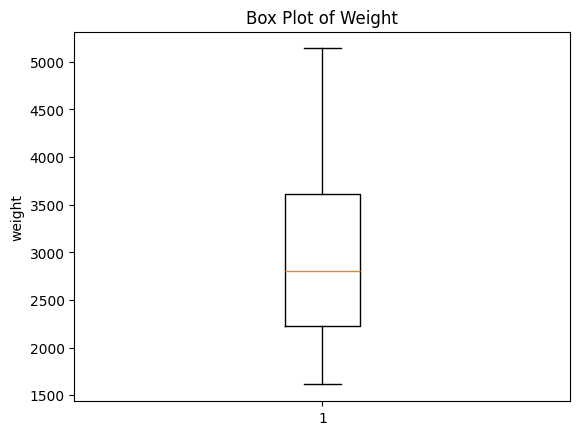

In [7]:
plt.boxplot(df["weight"].dropna(), vert=True)
plt.ylabel("weight")
plt.title("Box Plot of Weight")
plt.show() # means that after the median (around 2.5k), there is a sudden jump in the rest of the values, since the Q3 - Q2 is large

Text(0, 0.5, 'miles per gallon')

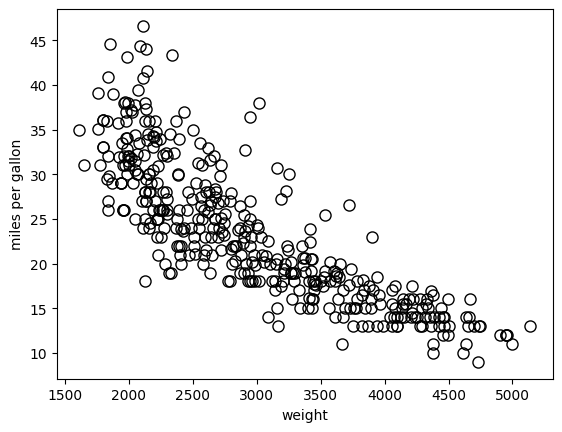

In [8]:
plt.plot(df["weight"], df["mpg"], 'o', markersize=8, fillstyle='none', color='black')
plt.xlabel("weight")
plt.ylabel("miles per gallon")

In [9]:
b1_hat = df["weight"].cov(df["mpg"])/df["weight"].var()

b0_hat = df["mpg"].mean() - b1_hat * (df["weight"].mean())

print("slope: ", b1_hat)
print("intercept: ", b0_hat)

slope:  -0.007676610063926469
intercept:  46.31736442026564


In [10]:
import statsmodels.api as sm

X = df["weight"]
y = df["mpg"]

X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     888.9
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          2.97e-103
Time:                        17:05:23   Log-Likelihood:                -1148.4
No. Observations:                 398   AIC:                             2301.
Df Residuals:                     396   BIC:                             2309.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.3174      0.795     58.243      0.0

Text(0, 0.5, 'MPG')

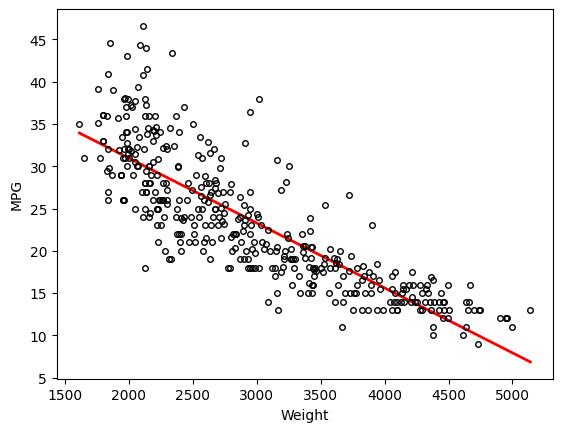

In [11]:
X_vals = np.linspace(X.min(), X.max(), 200)
X_vals_sm = sm.add_constant(X_vals)
y_vals = model.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")
plt.plot(X, y, 'o', markersize=4, fillstyle='none', color='black')
# plt.xscale('log')


plt.xlabel("Weight")
plt.ylabel("MPG")

Text(0.5, 0, 'weight')

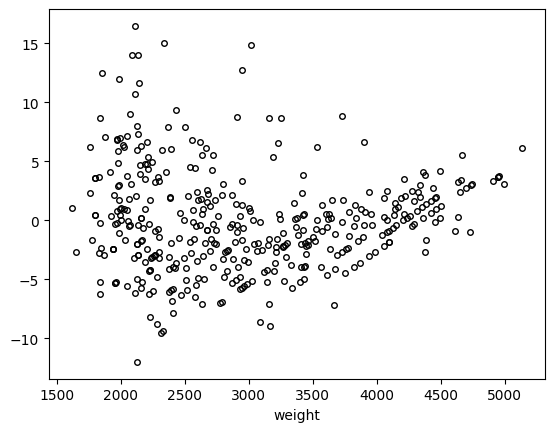

In [12]:
residuals = model.resid
fitted = model.fittedvalues
plt.plot(df["weight"], residuals, 'o', markersize=4, fillstyle='none', color='black') 
plt.xlabel("weight") # relationship doesnt seem linear as residuals dont have constant variance, there is a curve 

Text(0.5, 0, 'fitted values')

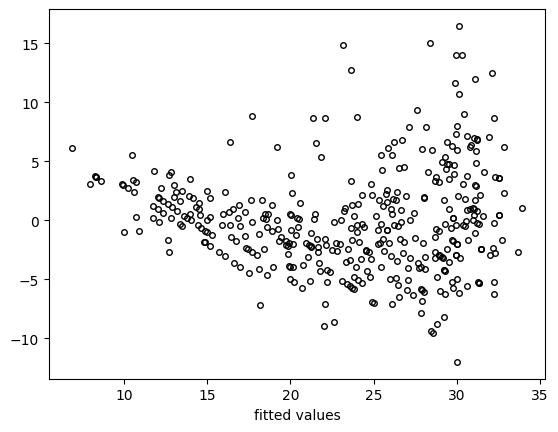

In [13]:
residuals = model.resid
fitted = model.fittedvalues
plt.plot(fitted, residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("fitted values")

In [14]:
X_log = np.log(df["weight"])

X_sm_log = sm.add_constant(X_log)

model_log = sm.OLS(y, X_sm_log).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     980.4
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          3.51e-109
Time:                        17:05:25   Log-Likelihood:                -1134.7
No. Observations:                 398   AIC:                             2273.
Df Residuals:                     396   BIC:                             2281.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        210.5270      5.976     35.227      0.0

Text(0.5, 1.0, 'residuals when y ~ log(weight)')

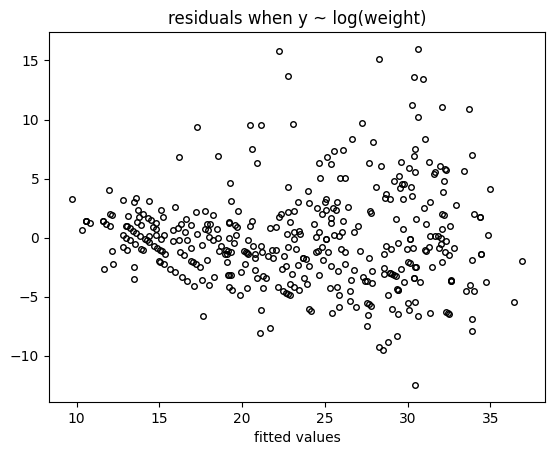

In [16]:
residuals_log = model_log.resid
fitted_log = model_log.fittedvalues

plt.plot(fitted_log, residuals_log, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("fitted values")
plt.title("residuals when y ~ log(weight)") # plot goes from violating linear to now being decently linear but violating homoskedacity

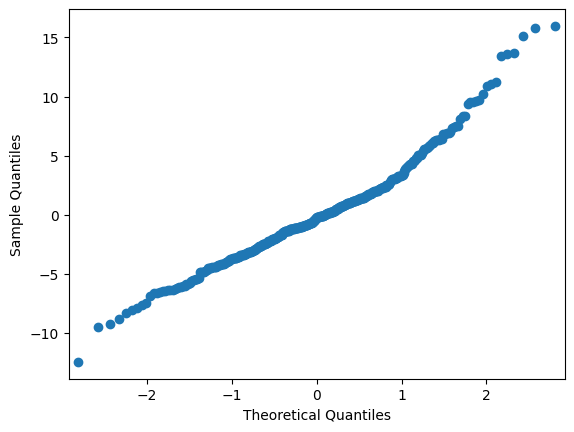

In [17]:
sm.qqplot(residuals_log) # fails towards the tail, Gaussian assumption is violated
plt.show()

-0.10999999999999988


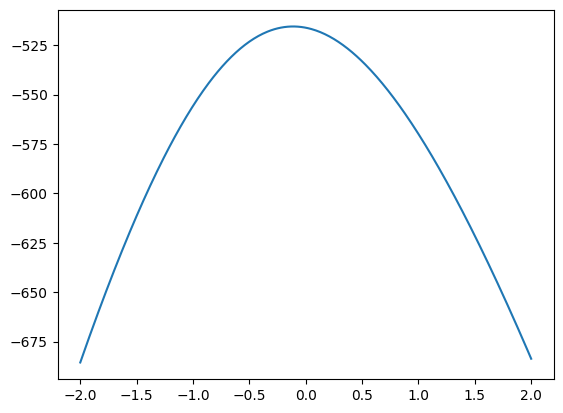

In [27]:
def boxcox(lmbd, y, X):
    if np.isclose(lmbd, 0):
        y_bc = np.log(y)
    else:
        y_bc = (y ** lmbd - 1)/lmbd
    
    bxcx_model = sm.OLS(y_bc, X).fit()

    rss = np.sum(bxcx_model.resid ** 2)
    n = len(y)

    llf = -n/2 * (np.log(rss/n)) + (lmbd-1) * np.sum(np.log(y))

    return llf


lambdas = np.linspace(-2, 2, 401)
llf_vals = [boxcox(l, y, X_sm_log) for l in lambdas]

plt.plot(lambdas, llf_vals)

lambda_hat = lambdas[np.argmax(llf_vals)]

print(lambda_hat)

In [30]:
# y_bc = ((y ** lambda_hat) - 1)/lambda_hat # this is the MLE estimate
y_bc = np.log(y)

model_bc = sm.OLS(y_bc, X_sm_log).fit()
print(model_bc.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     1287.
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          1.75e-126
Time:                        20:29:47   Log-Likelihood:                 153.46
No. Observations:                 398   AIC:                            -302.9
Df Residuals:                     396   BIC:                            -294.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.5219      0.235     49.056      0.0

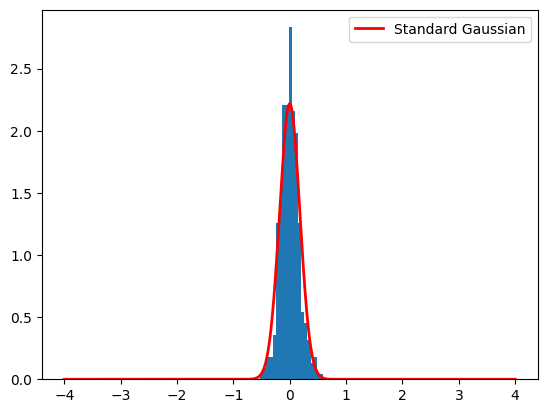

In [54]:
bc_residuals = model_bc.resid
_, bins, _ = plt.hist(bc_residuals, bins=20, density=True)
x = np.linspace(-4, 4, 1000)
mu, sigma = 0, 0.18
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)
plt.plot(x, pdf, 'r', linewidth=2, label='Standard Gaussian')

plt.legend()
plt.show() # Gaussian noise assumption seems to hold

Text(0, 0.5, 'log(mpg)')

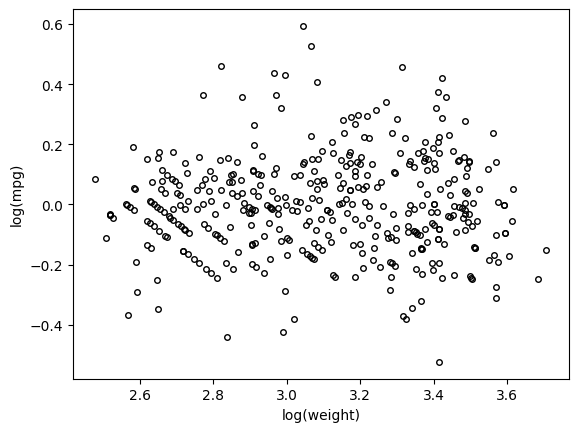

In [58]:
plt.plot(model_bc.fittedvalues, bc_residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.xlabel("log(weight)")
plt.ylabel("log(mpg)") # homoscedacity assumptions seem to get better

In [62]:
conf_interval = model_bc.conf_int(alpha=0.1)

print(conf_interval)

                0          1
const   11.134670  11.909143
weight  -1.106905  -1.009631


In [63]:
print(model_bc.pvalues)

const     2.319931e-170
weight    1.752225e-126
dtype: float64
